In [ ]:
#Imports gerais
import numpy as np
import cv2
import sys
from PIL import Image, ImageDraw, ImageFont


#Imports do colab
from google.colab.patches import cv2_imshow
from google.colab import files



In [ ]:
debug = True

Carrega a imagem e clarea o fundo: para clarear o fundo, converte-se a imagem para HSV, extrai-se o valor de V e aplica-se uma suavização agressiva. Depois dividi-se o valor de V original pelo V suavizado e cria-se uma nova imagem usando os H e S anteriores e o V obtido pela divisão. O resultado é uma imagem com fundo muito claro.

In [ ]:

res_num = input('Qual número do res: ')
img = cv2.imread(f'/content/drive/MyDrive/Projeto - Resistores/Resistores/Resistor_{res_num}.png')

# uploadImg = files.upload() # Permite subir imagens do seu computador
# imgFile = next(iter(uploadImg))
# img = cv2.imread(imgFile)


hsv = cv2.cvtColor(img, cv2.COLOR_BGR2HSV)
h,s,v = cv2.split(hsv)

v = cv2.GaussianBlur(v,(5,5),0)
bg = cv2.GaussianBlur(v,(101,101),0)
v2 = cv2.divide(v,bg,scale=255)

clahe = cv2.createCLAHE(clipLimit=2.0, tileGridSize=(8,8))
v2 = clahe.apply(v2)
final = cv2.merge((h,s,v2)) #Imagem com fundo muito claro para limiarização.

Qual número do res: 6


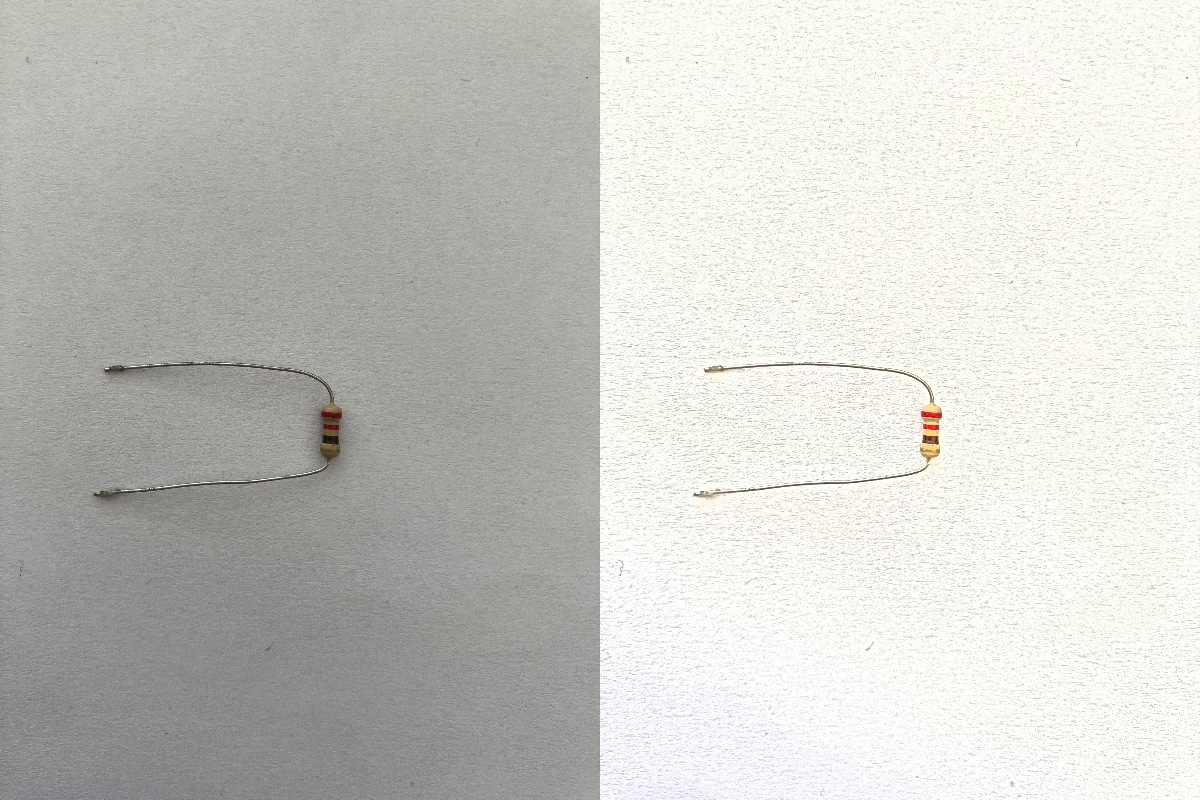

In [ ]:
if debug == True:
  imgD1 = cv2.resize(img,(600,800))
  finalDebug = cv2.cvtColor(final,cv2.COLOR_HSV2BGR)
  imgD2 = cv2.resize(finalDebug,(600,800))
  imgDebug = cv2.hconcat([imgD1, imgD2])
  cv2_imshow(imgDebug)

Define limiares e aplica limiarização para obter uma máscara que onde é branco indica a presença do resistor e onde é preto indica fundo.

In [ ]:
                #[H, S, V]
lower = np.array([0, 0, 170])
upper = np.array([180, 45, 255])
background = cv2.inRange(final, lower, upper)

# Inverte
mask = cv2.bitwise_not(background)

kernel = cv2.getStructuringElement(
    cv2.MORPH_ELLIPSE,
    (5,5)
)

mask = cv2.morphologyEx(
    mask,
    cv2.MORPH_CLOSE,
    kernel
)
mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, np.ones((3,3), np.uint8))



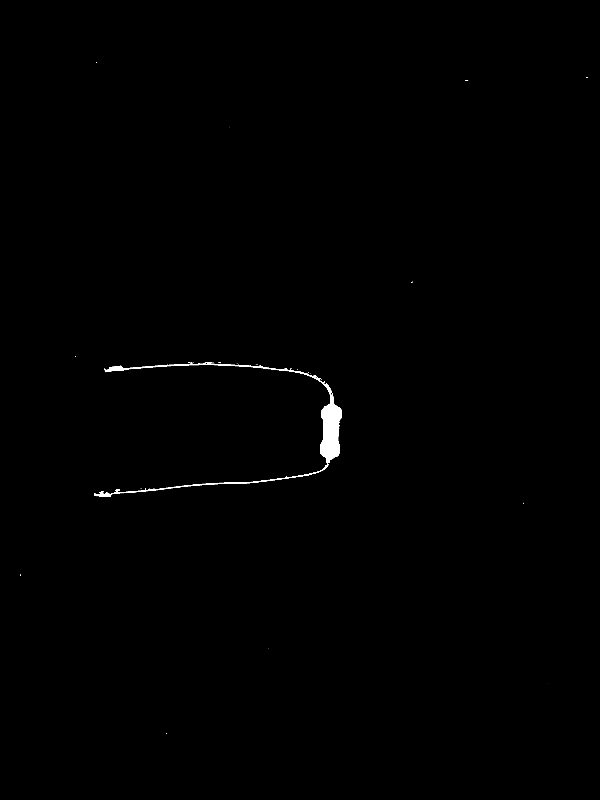

In [ ]:
if debug == True:
  cv2_imshow(cv2.resize(mask,(600,800)))

Remove as pernas do resistor: Usa transformada da distância para obter o raio do corpo do rersistor e usa esse tamanho para criar um kernel e aplicar uma abertura morfológica na máscarra. O resultado é exatamente a máscara indicando o corpo do resistor sem indicar as pernas.

A abertura morfológica é uma operação definida pela aplicação de uma erosão seguida de uma dilatação utilizando o mesmo elemento estruturante \(B\):

\[
A ∘ B = (A ⊖ B) ⊕ B
\]

em que \(A\) representa a imagem, \(⊖) a erosão e \(⊕) a dilatação. Essa operação remove regiões com lado menor que os lados do elemento estruturante e mantém regiões com lados maiores que os do elemento estruturante.


In [ ]:

contornos, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno_escolhido = max(contornos, key=cv2.contourArea)


radius = cv2.distanceTransform(mask, cv2.DIST_L2, 5).max()

L =int( radius if radius%2 > 0 else radius+ 1 )
kernel = cv2.getStructuringElement(
    cv2.MORPH_RECT,
    (L, L)
)


opening = cv2.morphologyEx(
    mask,
    cv2.MORPH_OPEN,
    kernel)

resistor = opening

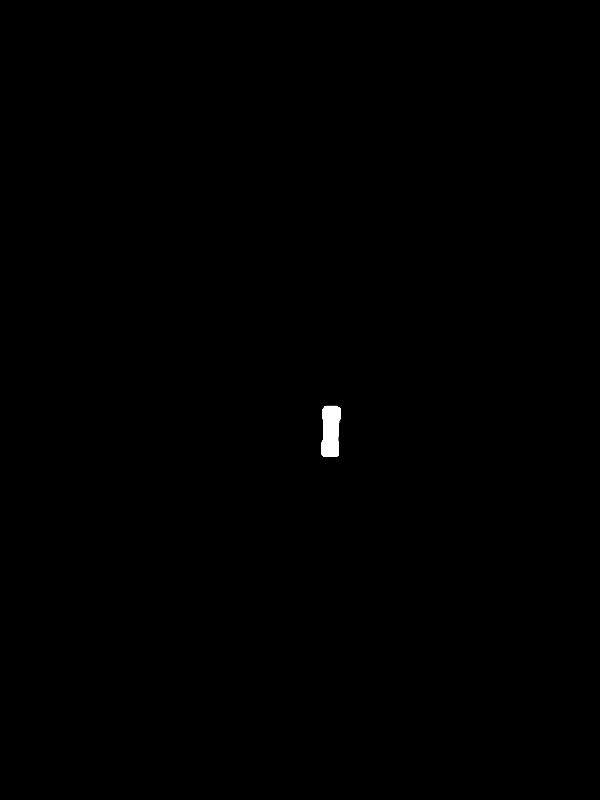

In [ ]:
if debug == True:
  cv2_imshow(cv2.resize(resistor,(600,800)))

Aplica a máscara na imagem e extrai os contornos da região a partir da máscara.


In [ ]:
resultado = cv2.bitwise_and(img, img, mask=resistor)
ContRes, _ = cv2.findContours(resistor, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
contorno  = max(ContRes, key=cv2.contourArea)

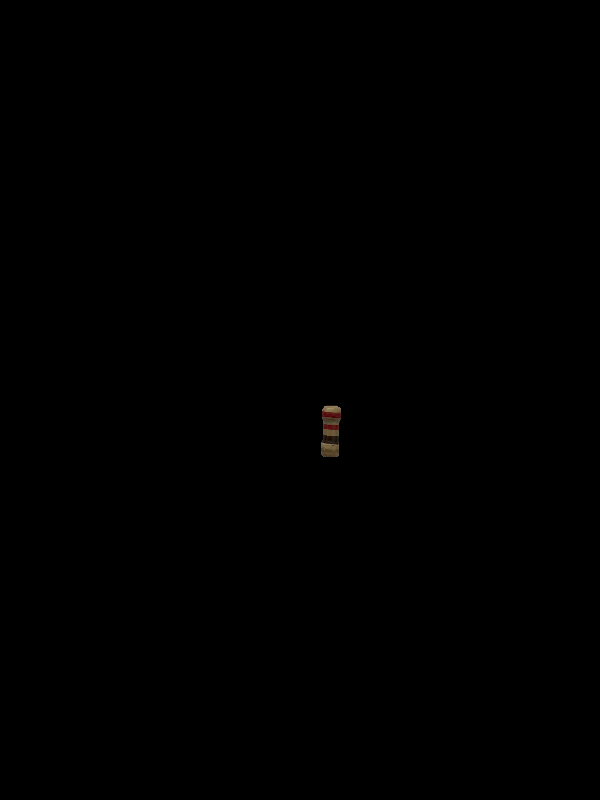

In [ ]:
if debug == True:
  cv2_imshow(cv2.resize(resultado,(600,800)))

A função abaixo rotaciona a imagem para que o resistor esteja em paralelo com o eixo X. A função cv2.minAreaRect retorna elementos do retângulo que engloba o contorno utilizado como entrada, sendo alguns desses elementos o ângulo de rotação do retângulo e as coordenadas de seu cento. Com essas informações, cria-se uma matriz de rotação que é utilizada para rotacionar a imagem e o contorno do resistor.

Como o ângulo retornado por cv2.minAreaRect é definido em relação ao lado de maior comprimento do retângulo, verifica-se se a altura é maior que a largura. Nesse caso, soma-se (90$^∘$) ao ângulo de rotação, de modo que o resistor seja corretamente alinhado ao eixo (X).

In [ ]:
def resPosit(img,contorno):

    rect = cv2.minAreaRect(contorno)
    (cx_rect, cy_rect), (w, h), angle = rect

    if w < h:
        angle = angle + 90

    M = cv2.getRotationMatrix2D((cx_rect, cy_rect), angle, 1.0)

    imgRotac = cv2.warpAffine(
        img,
        M,
        (img.shape[1], img.shape[0]),
        flags=cv2.INTER_LINEAR,
        borderMode=cv2.BORDER_CONSTANT,
        borderValue=(0, 0, 0)
    )

    contornoRotac = cv2.transform(contorno, M)

    output = [imgRotac, contornoRotac]

    return output


Com a imagem e o contorno rotacionado, ajusta-se a imagem para trabalhar apenas com a região em torno do reistor. Dessa forma, em vez de processsar uma imagem de 3000x4000, por exemplo, trabalha-se em uma região muito reduzida.

In [ ]:
imgRotac, contRotac = resPosit(img, contorno)
rectAtual = cv2.boundingRect(contRotac)
xAtual, yAtual, wAtual, hAtual = rectAtual

cx = xAtual + wAtual // 2
cy = yAtual + hAtual // 2

w_novo = 2 * wAtual
h_novo = 4 * hAtual


x1 = max(0, cx - w_novo // 2)
y1 = max(0, cy - h_novo // 2)
x2 = min(imgRotac.shape[1], cx + w_novo // 2)
y2 = min(imgRotac.shape[0], cy + h_novo // 2)

maskResAtual = np.zeros(final.shape[:2], dtype=np.uint8)
cv2.drawContours(maskResAtual, [contRotac], -1, 255, -1)


imgAtual = imgRotac[y1:y2, x1:x2]
maskResAtual = maskResAtual[y1:y2, x1:x2]

############################################################


contornoZoom, _ = cv2.findContours(maskResAtual, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
rectZoom = cv2.boundingRect(max(contornoZoom, key=cv2.contourArea))
xZoom, yZoom, wZoom, hZoom = rectZoom

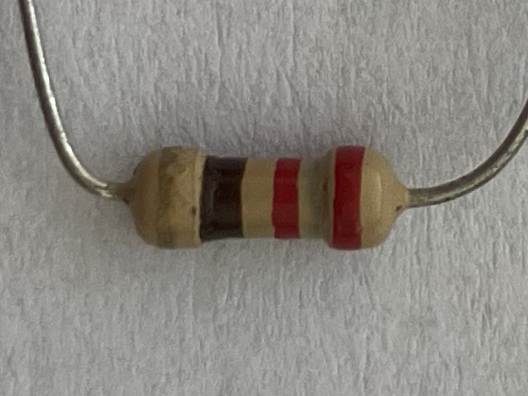

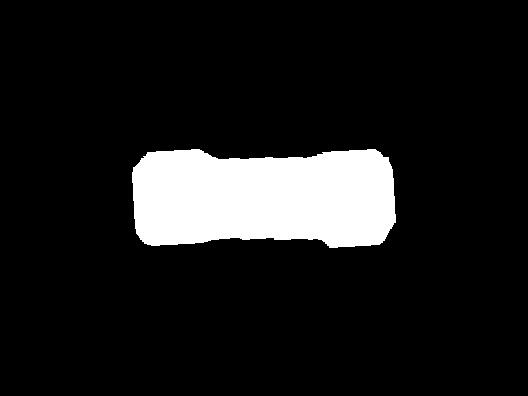

In [ ]:
if debug == True:
  cv2_imshow(imgAtual)
  cv2_imshow(maskResAtual)

A função maskFaixas tem como objetivo obter uma máscara contendo apenas as faixas coloridas do resistor. Inicialmente, é criado um elemento estruturante proporcional ao tamanho do resistor para as operações morfológicas.

Em seguida, calcula-se o histograma do canal de matiz (H) apenas na região do resistor. A matiz mais frequente é assumida como a cor predominante do corpo do resistor, permitindo gerar uma máscara que separa o corpo das faixas.

Como algumas faixas podem possuir matiz semelhante à do corpo, elas são recuperadas por meio de limiarizações no canal de saturação (S), para cores intensas, e na imagem em tons de cinza, para cores escuras. Por fim, todas as máscaras são combinadas e submetidas a uma abertura morfológica para remover ruídos, resultando na máscara final das faixas.


In [ ]:
def maskFaixas(mask, hc, sc, L):

  LFaixas =int( L*0.2 if radius%2 > 0 else L*0.2+ 1 )
  kernelFaixas = cv2.getStructuringElement(
      cv2.MORPH_RECT,
      (LFaixas, LFaixas)
  )

  hcc = hc[mask>0]

  histh = cv2.calcHist([hcc],[0],None, [179],[0,179])
  maxh = np.argmax(histh)

  maskhInv = cv2.inRange(hc, int(maxh - 12), int(maxh + 12)) #Máscara do corpo

  maskh = cv2.bitwise_and(
      cv2.bitwise_not(maskhInv),
      mask
  ) #Máscara do que não é corpo.

  maskh = cv2.morphologyEx(
      maskh,
      cv2.MORPH_OPEN,
      kernelFaixas)



  #Extração de cores vivas que foram filtrada como corpo.

  sb = cv2.bitwise_and(sc,sc,mask = maskhInv)
  _,masks = cv2.threshold(sb,150,255,cv2.THRESH_BINARY)

  masks = cv2.morphologyEx(
      masks,
      cv2.MORPH_OPEN,
      kernelFaixas)

  maskf = cv2.bitwise_or(maskh,masks)




  #Extração de cores escuras que foram filtradas como corpo.

  gray = cv2.cvtColor(blur,cv2.COLOR_BGR2GRAY)
  gray = cv2.bitwise_and(gray,gray,mask = maskhInv)

  _,maskgInv = cv2.threshold(gray,50,255,cv2.THRESH_BINARY)

  maskg = cv2.bitwise_and(
      cv2.bitwise_not(maskgInv),
      mask
  )

  maskg = cv2.morphologyEx(
      maskg,
      cv2.MORPH_OPEN,
      kernelFaixas)

  maskff = cv2.bitwise_or(maskf,maskg)

  maskff = cv2.morphologyEx(
      maskff,
      cv2.MORPH_OPEN,
      kernelFaixas)

  return maskff

Para obtenção das faixas primeiro é criada uma versão suavizada da imagem original para remover grandes variações entre os pixeis das faixas de cores, uniformizando a cor dos elementos. Dessa imagem, extrai-se os valores de H e S e aplica-se a função anterior.

In [ ]:
blur = cv2.GaussianBlur(imgAtual, (11,11), 0)

corpohsv = cv2.cvtColor(blur, cv2.COLOR_BGR2HSV)
hc,sc,vc = cv2.split(corpohsv)

maskFaixasH = maskFaixas(maskResAtual, hc, sc, L)
contornosFaixas, _ = cv2.findContours(maskFaixasH, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)


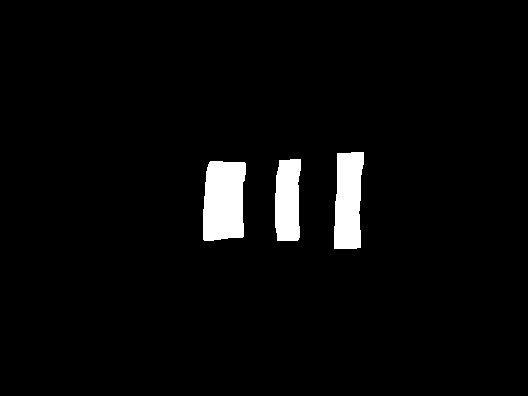

In [ ]:
if debug == True:
  cv2_imshow(maskFaixasH)

A função abaixo foi criada para tratamento das faixas. Em alguns casos, a máscara anterior pode encontrar duas faixas na mesma posição X. Isso acontece principalmente quando há reflexo de luz no meio das faixas, fazendo com que o processo de segmentação "divida" a faixa em duas. Nas próximas funções, o algoritmo espera 3 faixas, então a função irá tratar as faixas encontradas para que elas respeitem essa condição.

Primeiro, para remover faixas na mesma posição X, a função encontra o centroide de cada faixa a partir dos momentos geométricos do seu contorno, calculados pela função cv2.moments. Sejam ($M_{ij}$) os momentos da região, o centróide (($c_x$,$c_y$)) é obtido por:

$$
c_x=\frac{M_{10}}{M_{00}}, \qquad
c_y=\frac{M_{01}}{M_{00}}
$$

em que ($M_{00}$) corresponde à área do contorno, enquanto ($M_{10}$) e ($M_{01}$) representam os momentos de primeira ordem em relação aos eixos (x) e (y), respectivamente. Dessa forma, o centróide corresponde ao "centro de massa" da faixa, assumindo densidade uniforme.

Após o cálculo dos centróides, a função remove contornos cujos centróides estejam muito próximos no eixo (x), mantendo apenas aquele de maior área. Por fim, seleciona os três maiores contornos, correspondentes às três faixas do resistor, e retorna seus contornos e respectivos centróides. A função também retorna os centroides pois outras funções futuramente utilizam desses valores.

In [ ]:
def faixasHandling(contornosFaixas):

    dados = []

    for contorno in contornosFaixas:

        M = cv2.moments(contorno)

        if M["m00"] == 0:
            continue

        cx = M["m10"] / M["m00"]
        cy = M["m01"] / M["m00"]

        dados.append({
            "contorno": contorno,
            "centroide": (cx, cy),
            "area": cv2.contourArea(contorno)
        })

    # Remove contornos muito próximos no eixo X
    remover = set()

    for i in range(len(dados)):
        for j in range(i + 1, len(dados)):

            cx_i = dados[i]["centroide"][0]
            cx_j = dados[j]["centroide"][0]

            if abs(cx_i - cx_j) <= 5:

                if dados[i]["area"] < dados[j]["area"]:
                    remover.add(i)
                else:
                    remover.add(j)

    dados = [
        dados[i]
        for i in range(len(dados))
        if i not in remover
    ]

    if len(dados) >= 3:

        dados = sorted(
            dados,
            key=lambda d: d["area"],
            reverse=True
        )[:3]

    else:

        print('Menos de 3 faixas identificadas. Por favor, tire outra foto.')
        sys.exit()

    faixas = [d["contorno"] for d in dados]
    centroides = [d["centroide"] for d in dados]

    return faixas, centroides

In [ ]:
faixasTratadas, centros  = faixasHandling(contornosFaixas)

A função faixasSort determina a ordem correta das três faixas do resistor. Inicialmente, são extraídas as coordenadas dos centróides e calculadas as distâncias de cada faixa às bordas esquerda e direita do resistor.

Em seguida, identifica-se a faixa mais à esquerda, a mais à direita e, por exclusão, a faixa central. Para definir qual extremidade corresponde ao início da leitura, compara-se a menor distância de cada faixa extrema à borda mais próxima do resistor. A faixa que estiver mais próxima de uma extremidade é considerada a primeira faixa, definindo o sentido de leitura.

Por fim, os contornos e os centróides são reordenados de acordo com essa sequência e retornados para as etapas seguintes do algoritmo.


In [ ]:
def faixasSort(faixas, xRes, wRes, centros):

  xs = [c[0] for c in centros]
  ys = [c[1] for c in centros]


  # Distância até a borda esquerda e direita do resistor
  d_esq = [x - xRes for x in xs]
  d_dir = [xRes + wRes - x for x in xs]

  # Faixas mais à esquerda e mais à direita
  argmin = np.argmin(xs)
  argmax = np.argmax(xs)

  # Faixa do meio
  meio = ({0, 1, 2} - {argmin, argmax}).pop()

  FdArg1 = [d_esq[argmin], d_dir[argmin]]
  FdArg2 = [d_esq[argmax], d_dir[argmax]]

  # Quem estiver mais próximo de uma extremidade é a primeira faixa
  if min(FdArg1) < min(FdArg2):
      ordem = [argmin, meio, argmax]
  else:
      ordem = [argmax, meio, argmin]

  FaixasOrdenadas = [faixas[i] for i in ordem]
  CentrosOrdenados = [centros[i] for i in ordem]


  return FaixasOrdenadas, CentrosOrdenados, (d_dir, d_esq, ordem)

In [ ]:
faixasOrdenadas, centros, distancias = faixasSort(faixasTratadas, xZoom, wZoom, centros)

A função colorDecOut determina a cor de cada faixa a partir de seus centróides. Para cada centróide, é extraída uma janela de (5 × 5) pixels da imagem suavizada (blur), reduzindo a influência de ruídos e pequenas variações de cor.

Em seguida, a janela é convertida para o espaço de cores HSV, e calcula-se a média dos valores de matiz (H), saturação (S) e brilho (V). Esse vetor médio é utilizado pela função colorDec, responsável por classificar a cor da faixa.

Como duas ou mais faixas podem ser classificadas como pretas devido à baixa luminosidade, é realizado um tratamento adicional. Entre as faixas classificadas como pretas, identifica-se aquela com menor valor de brilho (V), mantendo-a como preta. Caso as demais tenham valor de V muito diferente da referência, são reclassificadas pela função colorDec, desconsiderando a possibilidade de serem pretas, reduzindo erros de classificação provocados por sombras ou variações de iluminação.


In [ ]:
def colorDecOut(centros,blur):

  colors = []
  corFaixas = []


  for xs, ys in centros:

      xs = int(xs)
      ys = int(ys)

      janela = blur[ys-2:ys+3, xs-2:xs+3]

      # Converte toda a janela para HSV
      janelaHSV = cv2.cvtColor(janela, cv2.COLOR_BGR2HSV)


      # Média dos pixels HSV da janela
      mediaHSV = np.mean(janelaHSV, axis=(0, 1))
      h, s, v = mediaHSV

      color = np.array([
          h,
          s,
          v
      ], dtype=np.float32)

      colors.append(color)
      corFaixas.append(colorDec(color))


  # Tratamento especial para mais de uma faixa preta

  if corFaixas.count('Preto') > 1:

      minBlack = min(
        cor[2]
        for nome, cor in zip(corFaixas, colors)
        if nome == 'Preto'
      )

      for idxCor, cor in enumerate(colors):
          if corFaixas[idxCor] == 'Preto' and np.abs(cor[2] - minBlack) >= 5:
              corFaixas[idxCor] = colorDec(cor, canBlack=False)

  return corFaixas

A função colorDec classifica a cor de uma faixa a partir de seu vetor médio no espaço de cores HSV. Inicialmente, apenas a componente de matiz (H) é utilizada para calcular a distância entre a cor medida e os valores de referência das cores do código de resistores. A cor cuja distância é mínima é selecionada como classificação inicial.

Para a cor vermelha, considera-se a natureza circular da matiz no espaço HSV, comparando as distâncias aos valores (H = 0) e (H = 180), que representam a mesma tonalidade.

Em seguida, a classificação é refinada utilizando os valores de saturação (S) e brilho (V). Essa etapa permite distinguir cores de matiz semelhante, como vermelho, marrom e laranja, além de identificar tons de cinza e preto, que apresentam baixa saturação e/ou baixo brilho. O parâmetro canBlack controla se a cor preta pode ser atribuída, sendo utilizado para evitar classificações repetidas de preto durante o pós-processamento.


In [ ]:
def colorDec(cor,canBlack = True):


    centroCores = {
        'Vermelho':[0,180],
        'Laranja': 10,
        'Amarelo':25,
        'Verde':50,
        'Azul':110,
        'Violeta':130
    }

    melhor_cor = None
    menor_dist = float('inf')
    hcor = cor[0]

    for nome, centro in centroCores.items():

        if nome == 'Vermelho':
          dist1 = np.linalg.norm(np.array(hcor) - np.array(centro[0]))
          dist2 = np.linalg.norm(np.array(hcor) - np.array(centro[1]))
          dist = min(dist1,dist2)

        else:
          dist = np.linalg.norm(
              np.array(hcor) - np.array(centro)
          )

        if dist < menor_dist:
            menor_dist = dist
            melhor_cor = nome

    if melhor_cor == 'Vermelho' or melhor_cor == 'Laranja':
            if (cor[1] < 70 and (30 < cor[2] < 60)) or (cor[1] < 20 and (40 < cor[2] < 100)):
                if cor[2] < 30 and canBlack:
                    melhor_cor = 'Preto'

                else:
                    melhor_cor = 'Cinza'

            elif cor[2] < 70:
                if cor[2] < 15 and canBlack:
                    melhor_cor = 'Preto'

                else:
                    melhor_cor = 'Marrom'

            elif cor[2] > 100:
                melhor_cor = 'Laranja'

    else:
            if (cor[1] < 70 and cor[2] < 60) or (cor[1] < 20 and cor[2] < 100):
                if cor[2] < 30 and canBlack:
                    melhor_cor = 'Preto'

                else:
                    melhor_cor = 'Cinza'

            elif cor[2] < 20 and canBlack:
                melhor_cor = 'Preto'

    # print(melhor_cor, menor_dist)
    return melhor_cor


In [ ]:
corFaixas = colorDecOut(centros, blur)

In [ ]:
if debug == True:
  print(corFaixas)

['Vermelho', 'Vermelho', 'Marrom']


In [ ]:
def resistencia(cores):

  colorcode = {'Preto':0,
               'Marrom':1,
               'Vermelho':2,
               'Laranja':3,
               'Amarelo':4,
               'Verde':5,
               'Azul':6,
               'Violeta':7,
               'Cinza':8,
               }
  holder = []

  for cor in cores:
    holder.append(colorcode[cor])


  resist = (holder[0]*10 + holder[1])*10**(holder[2])
  resist = formatRes(resist)
  return resist
  print(f'Seu resistor é de {resist} omhs! ')


In [ ]:
def formatRes(r):
    omega = "\u03A9"

    if r < 1e3:
        return f'{r:.0f} {omega}'
    elif r < 1e6:
        return f'{r/1e3:.1f} k{omega}'
    elif r < 1e9:
        return f'{r/1e6:.1f} M{omega}'
    else:
        return f'{r/1e9:.1f} G{omega}'

In [ ]:
resValue  = resistencia(corFaixas)

In [ ]:
if debug == True:
  print(resValue)

220 Ω


A função abaixo faz o ajuste da imagem de saída do programa. Primeiro ele vai ajustar o resistor para a posição de leitura (da esquerda para a direita) verificando se a faixa determinada como primeira está mais próximo da esquerda ou da direita da borda do resistor. Caso esteja mais próximo da direita, a função espelha a imgaem e os contornos.

Na sequência, o algoritmo desenha retângulos em volta dos contornos da faixa, para melhor apresentá-los na saída.

Por fim, chama a função imgWrite para escrever sobre a imagem o valor da resistência.

In [ ]:
def finalAdjustment(imgFinal, distancias, Faixas, resValue):

  d_dir, d_esq, ordem = distancias
  FaixasFlip = [c.copy() for c in Faixas]
  primeira = ordem[0]



  if d_dir[primeira] < d_esq[primeira]:

      imgFinal = cv2.flip(imgFinal, 1)
      largura = imgFinal.shape[1]


      for c in FaixasFlip:
          c[:, 0, 0] = largura - 1 - c[:, 0, 0]



  for i, faixa in enumerate(FaixasFlip):

      x, y, w, h = cv2.boundingRect(faixa)

      # retângulo da faixa
      cv2.rectangle(imgFinal, (x, y), (x + w, y + h), (255, 0, 0), 2)

      # índice da faixa
      cv2.putText(
          imgFinal,
          str(i + 1),
          (x, y - 10),
          cv2.FONT_HERSHEY_SIMPLEX,
          0.7,
          (255, 0, 0),
          2
      )


  imgFinal = imgWrite(imgFinal.copy(), resValue)
  return imgFinal


A função imgWrite é responsável por inserir na imagem final uma anotação contendo o valor do resistor identificado durante o processamento. Inicialmente, a imagem é convertida do formato BGR, utilizado pelo OpenCV, para o formato RGB, compatível com a biblioteca PIL, que oferece maior qualidade e flexibilidade para a renderização de textos. Em seguida, é definida a fonte que será utilizada e é construída a mensagem no formato "Resistor de x Ω .

Para garantir que a anotação permaneça legível independentemente do conteúdo da imagem, a função calcula as dimensões ocupadas pelo texto e desenha um retângulo branco na região correspondente, que atua como plano de fundo. Posteriormente, o texto é escrito em preto sobre esse retângulo, proporcionando maior contraste visual. Por fim, a imagem é convertida novamente para o formato BGR, permitindo sua utilização pelas demais funções do OpenCV, e é retornada já contendo a identificação do valor do resistor.


In [ ]:
def imgWrite(img, text):

  img_pil = Image.fromarray(cv2.cvtColor(img, cv2.COLOR_BGR2RGB))

  draw = ImageDraw.Draw(img_pil)
  font = ImageFont.truetype(
      "/usr/share/fonts/truetype/liberation2/LiberationSans-Regular.ttf", #Essa fonte funciona apenas no Colab
      32
  )

  draw.text((20, 20), f'Resistor de {text}', font=font, fill=(0,0,0))


  texto = f'Resistor de {text}'

  bbox = draw.textbbox((20, 20), texto, font=font)

  draw.rectangle(
      bbox,
      fill="white"
  )

  draw.text(
      (20, 20),
      texto,
      font=font,
      fill="black"
  )

  img = cv2.cvtColor(np.array(img_pil), cv2.COLOR_RGB2BGR)

  return img

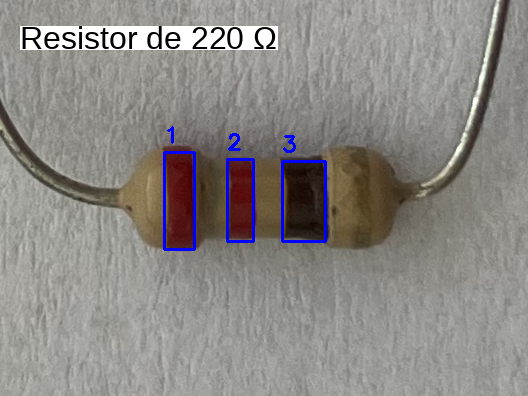

In [ ]:
imgFinal = finalAdjustment(imgAtual.copy(),distancias, faixasOrdenadas, resValue)
cv2_imshow(imgFinal)